## Importing libraries and loading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

In [2]:
df_ab_hist = pd.read_csv('/content/ab_test_task_historical_data.csv')
df_ab = pd.read_csv('/content/ab_test_task_data.csv')

## Understanding necessary test parameters on historical data

In [3]:
df_ab_hist.head()

,id_user,date_reg,date_first_payment,date_spent_15_credits
0,1,2023-03-01 00:00:09.068945 UTC,2023-03-01 02:06:31.472018 UTC,2023-03-01 02:00:38.000000 UTC
1,2,2023-03-01 00:00:25.615471 UTC,NaN,2023-03-01 00:17:38.000000 UTC
2,3,2023-03-01 00:00:39.084989 UTC,2023-03-01 00:52:37.812217 UTC,2023-03-01 00:18:53.000000 UTC
3,4,2023-03-01 00:00:42.779311 UTC,NaN,NaN
4,5,2023-03-01 00:00:42.872660 UTC,NaN,NaN


In [4]:
df_ab_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_user                59758 non-null  int64 
 1   date_reg               59758 non-null  object
 2   date_first_payment     3257 non-null   object
 3   date_spent_15_credits  22268 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB


In [5]:
date_cols_hist = ['date_reg', 'date_first_payment', 'date_spent_15_credits']
for col in date_cols_hist:
    df_ab_hist[col] = pd.to_datetime(df_ab_hist[col])

In [6]:
df_ab_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id_user                59758 non-null  int64              
 1   date_reg               59758 non-null  datetime64[ns, UTC]
 2   date_first_payment     3257 non-null   datetime64[ns, UTC]
 3   date_spent_15_credits  22268 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), int64(1)
memory usage: 1.8 MB


In [7]:
df_hist_target = df_ab_hist[df_ab_hist['date_spent_15_credits'].notna()].copy()
df_hist_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22268 entries, 0 to 59754
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id_user                22268 non-null  int64              
 1   date_reg               22268 non-null  datetime64[ns, UTC]
 2   date_first_payment     3202 non-null   datetime64[ns, UTC]
 3   date_spent_15_credits  22268 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), int64(1)
memory usage: 869.8 KB


In [8]:
baseline_cr = df_hist_target['date_first_payment'].count()/df_hist_target['date_spent_15_credits'].count()
print(f"Baseline Conversion Rate: {baseline_cr:.2%}")

Baseline Conversion Rate: 14.38%


In [9]:
df_hist_target['reg_day'] = df_hist_target['date_reg'].dt.date

In [10]:
daily_target_users = df_hist_target.groupby('reg_day')['id_user'].count().mean()
print(f"Average number of target users per day: {daily_target_users:.0f}")

Average number of target users per day: 2474


The sample size for one group, determined using an online calculator, is 9,460 users (MDE=10%).

In [12]:
sample_size = 9460*2
print(f"Minimum sample size for the test: {sample_size}")
days_needed = sample_size / daily_target_users
print(f"Minimum test duration: {days_needed:.0f} days")

Minimum sample size for the test: 18920
Minimum test duration: 8 days


Is there seasonality?

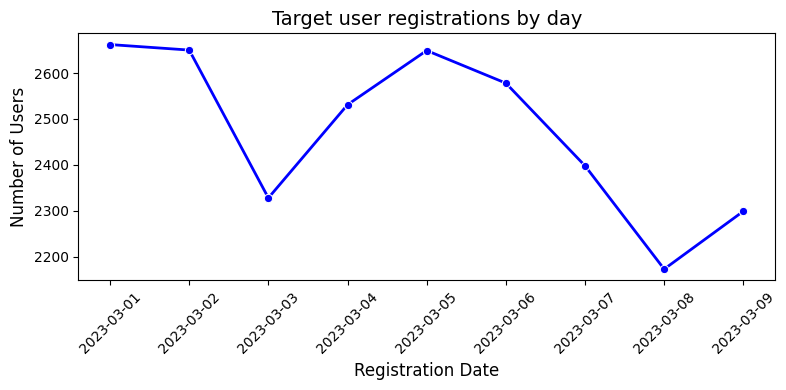

In [48]:
daily_users = df_hist_target.groupby('reg_day')['id_user'].nunique().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=daily_users, x='reg_day', y='id_user', marker='o', color='blue', linewidth=2)

plt.title('Target user registrations by day', fontsize=14)
plt.xlabel('Registration Date', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How many days pass between registration and spending 15 credits, and between registration and the first payment?

In [15]:
df_hist_target['reg_to_payment'] = (df_hist_target['date_first_payment'] - df_hist_target['date_reg']).dt.days
df_hist_target['reg_to_spend'] = (df_hist_target['date_spent_15_credits'] - df_hist_target['date_reg']).dt.days

In [16]:
df_hist_target['reg_to_spend'].value_counts().head()

,count
reg_to_spend,
0,15015
1,1400
2,702
3,489
4,356


In [17]:
df_hist_target['reg_to_spend'].describe()

,reg_to_spend
count,22268.000000
mean,8.850548
std,29.187872
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,290.000000


In [18]:
df_hist_target['reg_to_spend'].median()

0.0

In [19]:
df_hist_target['reg_to_spend'].mean()

np.float64(8.850547871384947)

<Axes: xlabel='reg_to_spend', ylabel='Count'>

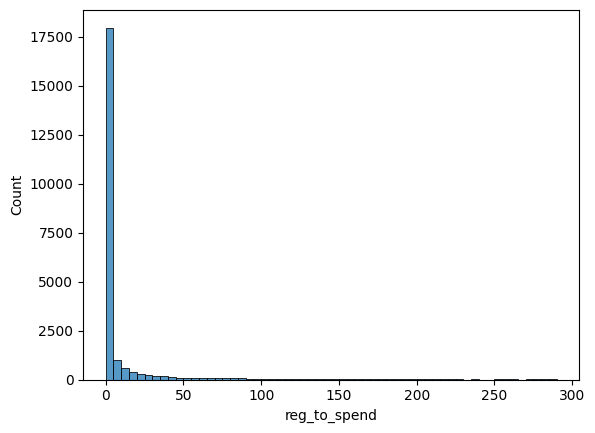

In [20]:
sns.histplot(data=df_hist_target, x="reg_to_spend", binwidth=5)

In [21]:
df_hist_target['reg_to_payment'].value_counts().head()

,count
reg_to_payment,
0.0,1698
1.0,249
2.0,163
3.0,92
5.0,61


In [22]:
df_hist_target['reg_to_payment'].describe()

,reg_to_payment
count,3202.000000
mean,16.224859
std,40.651259
min,0.000000
25%,0.000000
50%,0.000000
75%,7.000000
max,285.000000


In [23]:
df_hist_target['reg_to_payment'].median()

0.0

In [24]:
df_hist_target['reg_to_payment'].mean()

np.float64(16.224859462835727)

How many days have passed since the 15 credits were spent and the first payment?

In [25]:
df_hist_target['spend_to_payment'] = (df_hist_target['date_first_payment'] - df_hist_target['date_spent_15_credits']).dt.days
df_hist_target['spend_to_payment'].value_counts().head()

,count
spend_to_payment,
0.0,1904
-1.0,387
1.0,169
2.0,98
3.0,46


There is not enough data to determine whether there is seasonality. \
The 75th percentile of days to spend 15 credits is 2 days, the median is 0 days; \
the 75th percentile of days to pay is 7 days, the median is 0 days. \
A duration of 8 days should be sufficient for the test.

In [26]:
# checking the value from the calculator
import scipy.stats as stats
import statsmodels.stats.api as sms

# Parameters for calculating sample size
alpha = 0.05  # Significance level (5%)
power = 0.80  # Power of the test (80%)
mde_relative = 0.10  # Minimum Detectable Effect (expect +10% increase from the baseline conversion)
target_cr = baseline_cr * (1 + mde_relative)

effect_size = sms.proportion_effectsize(baseline_cr, target_cr)

# Calculating the required number of users per group
required_n_per_group = sms.NormalIndPower().solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)
required_n_per_group = int(np.ceil(required_n_per_group))
total_required_users = required_n_per_group * 2

print(f"Required users per group: {required_n_per_group}")
print(f"Total target users for the test: {total_required_users}")

# How many days does it take for the test?
days_required = total_required_users / daily_target_users
print(f"Required test duration: {np.ceil(days_required)} days")

Required users per group: 9727
Total target users for the test: 19454
Required test duration: 8.0 days


## Exploring test data

In [27]:
df_ab.head()

,id_user,date_reg,date_first_payment,date_spent_15_credits,date_reminder,match
0,1,2023-03-14 08:37:01.855460 UTC,2023-03-14 11:25:23.962741 UTC,2023-03-14 09:15:31.000000 UTC,2023-03-14 09:04:03.823970 UTC,1
1,2,2023-03-14 08:37:20.988023 UTC,NaN,NaN,NaN,0
2,3,2023-03-14 08:39:01.389639 UTC,NaN,2023-03-14 08:53:21.000000 UTC,2023-03-14 08:46:43.971330 UTC,0
3,4,2023-03-14 08:39:18.222582 UTC,NaN,NaN,2023-03-14 09:18:04.290338 UTC,0
4,5,2023-03-14 08:40:40.216560 UTC,NaN,NaN,NaN,1


In [28]:
df_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   id_user                125217 non-null  int64 
 1   date_reg               125217 non-null  object
 2   date_first_payment     7237 non-null    object
 3   date_spent_15_credits  51553 non-null   object
 4   date_reminder          15208 non-null   object
 5   match                  125217 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 5.7+ MB


In [29]:
date_cols_ab = ['date_reg', 'date_first_payment', 'date_spent_15_credits', 'date_reminder']
for col in date_cols_ab:
    df_ab[col] = pd.to_datetime(df_ab[col])

In [30]:
df_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   id_user                125217 non-null  int64              
 1   date_reg               125217 non-null  datetime64[ns, UTC]
 2   date_first_payment     7237 non-null    datetime64[ns, UTC]
 3   date_spent_15_credits  51553 non-null   datetime64[ns, UTC]
 4   date_reminder          15208 non-null   datetime64[ns, UTC]
 5   match                  125217 non-null  int64              
dtypes: datetime64[ns, UTC](4), int64(2)
memory usage: 5.7 MB


In [31]:
split = df_ab.groupby('match')['id_user'].nunique()
split

,id_user
match,
0,62568
1,62649


In [32]:
df_ab_target = df_ab[df_ab['date_spent_15_credits'].notna()].copy()
df_ab_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51553 entries, 0 to 125213
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id_user                51553 non-null  int64              
 1   date_reg               51553 non-null  datetime64[ns, UTC]
 2   date_first_payment     7145 non-null   datetime64[ns, UTC]
 3   date_spent_15_credits  51553 non-null  datetime64[ns, UTC]
 4   date_reminder          14978 non-null  datetime64[ns, UTC]
 5   match                  51553 non-null  int64              
dtypes: datetime64[ns, UTC](4), int64(2)
memory usage: 2.8 MB


In [33]:
slit_target = df_ab_target.groupby('match')['id_user'].nunique()
slit_target

,id_user
match,
0,25695
1,25858


The sample size exceeds the previously determined minimum required.

In [34]:
min_reg = df_ab['date_reg'].min()
max_reg = df_ab['date_reg'].max()

test_duration = max_reg - min_reg
print("Test duration: ", test_duration)

Test duration:  34 days 22:31:55.015576


The test lasted longer than the minimum required 8 days.

In [35]:
df_ab_target_reminder = df_ab_target[df_ab_target['date_reminder'].notna()].copy()
df_ab_target_reminder.groupby('match')['id_user'].nunique()

,id_user
match,
0,59
1,14919


In [36]:
df_ab_target_notreminder = df_ab_target[df_ab_target['date_reminder'].isna()].copy()
df_ab_target_notreminder.groupby('match')['id_user'].nunique()

,id_user
match,
0,25636
1,10939


In [37]:
df_anomalies = df_ab[df_ab['date_reminder'] < df_ab['date_spent_15_credits']].copy()
df_anomalies['match'].value_counts()


,count
match,
1,98
0,58


## Performing A/B test

**Null hypothesis**: \
A pinned chat reminder message does not increase first-time payment conversion among
users who spent 15 or more credits.
Any difference in the metric between groups is due to chance.\
\
**Alternative hypothesis:** \
A pinned reminder message in chat statistically significantly increases conversion to the first payment among users who have spent 15 or more credits.

In [38]:
successes_control = df_ab_target[df_ab_target['match'] == 0]['date_first_payment'].notna().sum()
successes_test = df_ab_target[df_ab_target['match'] == 1]['date_first_payment'].notna().sum()

total_control = df_ab_target[df_ab_target['match'] == 0]['id_user'].count()
total_test = df_ab_target[df_ab_target['match'] == 1]['id_user'].count()

counts = [successes_control, successes_test]
nobs = [total_control, total_test]

z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')

print(f"Z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Z-statistic: -2.5036
p-value: 0.0061


In [39]:
print(total_control, total_test)
print(successes_control, successes_test)

25695 25858
3463 3682


In [40]:
cr_control = successes_control/total_control
cr_test = successes_test/total_test
print(f"CR control: {cr_control:.4f}")
print(f"CR test: {cr_test:.4f}")

CR control: 0.1348
CR test: 0.1424


In [41]:
ci_control = proportion_confint(successes_control, total_control, alpha=0.05, method='normal')
ci_test = proportion_confint(successes_test, total_test, alpha=0.05, method='normal')

In [42]:
print(f"Control 95% CI: ({ci_control[0]:.2%}, {ci_control[1]:.2%})")
print(f"Test 95% CI: ({ci_test[0]:.2%}, {ci_test[1]:.2%})")

Control 95% CI: (13.06%, 13.89%)
Test 95% CI: (13.81%, 14.67%)


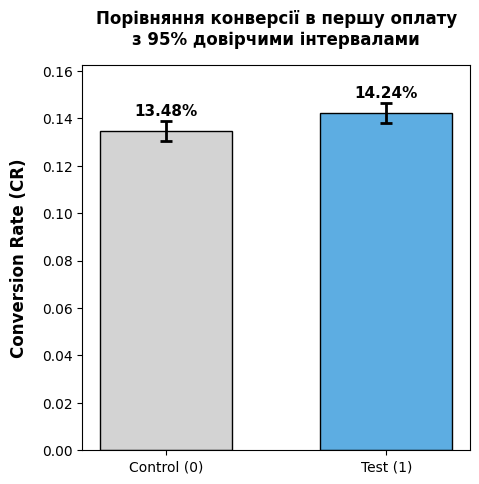

In [47]:
# Distance from conversion to interval boundary
err_control = cr_control - ci_control[0]
err_test = cr_test - ci_test[0]

groups = ['Control (0)', 'Test (1)']
conversion_rates = [cr_control, cr_test]
errors = [err_control, err_test]

plt.figure(figsize=(5, 5))

# Draw columns with whiskers (yerr is responsible for the whiskers, capsize makes horizontal serifs)
bars = plt.bar(groups, conversion_rates, yerr=errors, capsize=4,
               color=['#D3D3D3', '#5DADE2'], edgecolor='black', width=0.6, error_kw={'lw': 2, 'capthick': 2})

# Setting up a beautiful display
plt.ylabel('Conversion Rate (CR)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Порівняння конверсії в першу оплату\nз 95% довірчими інтервалами', fontsize=12, fontweight='bold', pad=15)

# Add text labels with exact percentages above each column
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Slightly raise the upper border of the graph so that the captions do not merge with the frame
plt.ylim(0, max(conversion_rates) + 0.02)

plt.show()

## Conclusion

**Key Solution**: Implement pinned reminders for users with 5 or fewer credits remaining on their account. \
\
**Justification**:
1. Statistical significance and hypothesis testing: \
According to the results of the one-sided Z-test of proportions, the obtained p-value is less than the established significance level of alpha = 0.05.
This gives us grounds to reject the null hypothesis of no effect or negative impact of the feature in favor of the
alternative hypothesis. We claim with 95% confidence that the recorded increase in the metric is a natural
result of the implementation of the reminder, and not random data noise.
2. Metric Performance (among the target audience with 15 credits spent): \
The first payment conversion in the Control Group (A) was 13.48% (3,463 paying users out of 25,695).
The first payment conversion in the Test Group (B) increased to 14.24% (3,682 paying users out of 25,858).
The relative lift of the metric is +5.65% (the absolute lift is +0.76 percentage points).